In [4]:
import numpy as np

def find_connected_components(matrix):
    n = len(matrix)
    visited = [False] * n
    components = []

    def dfs(node, comp):
        visited[node] = True
        comp.append(node)
        for neighbor, connected in enumerate(matrix[node]):
            if connected and not visited[neighbor]:
                dfs(neighbor, comp)

    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    return components

def generate_netlist(sequence, matrix, filename='output.net'):
    components_set = set()
    pin_map = {}
    comp_id = 1

    # Generate pin mapping for net names
    for name in sequence:
        base = name.split('_')[0]
        if base not in pin_map:
            pin_map[base] = {}
        if '_' in name:
            pin = name.split('_')[1]
            pin_map[base][pin] = name
        else:
            pin_map[base]['1'] = name  # for power pins or non-transistor nodes

    # Write netlist
    with open(filename, 'w') as f:
        f.write("(export (version D)\n\n  (components\n")

        # Declare components
        for comp in set(name.split('_')[0] for name in sequence):
            f.write(f"    (comp (ref {comp})\n")
            f.write(f"      (value {comp})\n")
            f.write(f"      (footprint Connector_PinHeader_1x01)\n")
            f.write(f"    )\n")

        f.write("  )\n\n  (nets\n")

        connected_components = find_connected_components(matrix)
        for idx, group in enumerate(connected_components, start=1):
            f.write(f"    (net (code {idx}) (name \"Net-{idx}\")\n")
            for node_idx in group:
                node = sequence[node_idx]
                comp = node.split('_')[0]
                pin = node.split('_')[1] if '_' in node else '1'
                f.write(f"      (node (ref {comp}) (pin {pin}))\n")
            f.write("    )\n")

        f.write("  )\n)")
    print(f"Netlist written to {filename}")


In [5]:
sequence = ['VDD', 'VSS', 'VIN1', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B']
matrix = np.array([
    [0,0,0,0,1,1,0,0],
    [0,0,0,0,0,0,0,1],
    [0,0,0,0,0,0,1,0],
    [0,0,0,0,1,1,1,1],
    [1,0,0,1,0,1,0,0],
    [1,0,0,1,1,0,0,0],
    [0,0,1,1,0,0,0,0],
    [0,1,0,1,0,0,0,0],
])

generate_netlist(sequence, matrix.tolist())


Netlist written to output.net


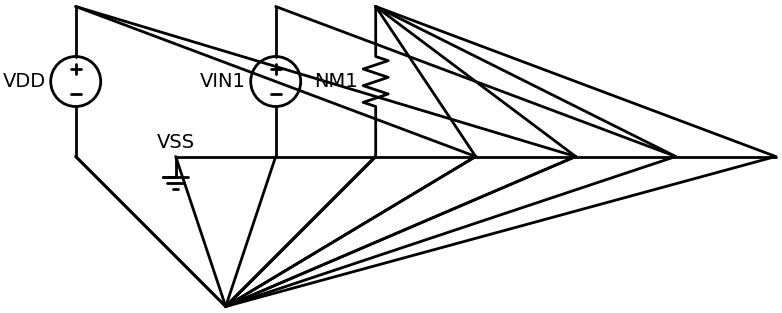

In [8]:
import schemdraw
import schemdraw.elements as elm
import numpy as np

# Define the sequence of components
sequence = ['VDD', 'VSS', 'VIN1', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B']

# Matrix for connections
matrix = np.array([
    [0, 0, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1, 1, 1, 1],
    [1, 0, 0, 1, 0, 1, 0, 0],
    [1, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 0, 0, 0],
])

# Initialize drawing
d = schemdraw.Drawing()

# Place components as nodes
components = {}
x_pos = 0
for i, name in enumerate(sequence):
    y_pos =  1  # Vertically spaced
    if name == 'NM1':
        components[name] = d.add(elm.Resistor().label(name).at((x_pos, y_pos)))
    elif name == 'VDD':
        components[name] = d.add(elm.SourceV().label(name).at((x_pos, y_pos)))
    elif name == 'VSS':
        components[name] = d.add(elm.Ground().label(name).at((x_pos, y_pos)))
    elif name == 'VIN1':
        components[name] = d.add(elm.SourceV().label(name).at((x_pos, y_pos)))
    else:
        components[name] = d.add(elm.Wire().at((x_pos, y_pos)))
    x_pos += 2  # Space components horizontally

# Connect components based on the matrix
for i in range(len(sequence)):
    for j in range(len(sequence)):
        if matrix[i, j] == 1:
            d.add(elm.Wire().at(components[sequence[i]].end).to(components[sequence[j]].start))

# Show the drawing
d.draw()


In [2]:
import schemdraw
import schemdraw.elements as elm

# Initialize drawing
d = schemdraw.Drawing()

# Create components
VDD = d.add(elm.SourceV().label('VDD').up().at((0, 0)))
VIN1 = d.add(elm.SourceV().label('VIN1').down().at((3, 0)))
VSS = d.add(elm.Ground().label('VSS').down().at((6, 0)))

# Create NMOS4 transistor (N-channel MOSFET)
nmos = d.add(elm.NMOS().at((3, -2)).up())

# Connect VDD to the drain of the NMOS
d.add(elm.Wire().from(VDD.end).to(nmos.drain))

# Connect VIN1 to the gate of the NMOS
d.add(elm.Wire().from(VIN1.end).to(nmos.gate))

# Connect the source of the NMOS to VSS
d.add(elm.Wire().from(nmos.source).to(VSS.start))

# Show the drawing
d.draw()


SyntaxError: invalid syntax (3693429623.py, line 16)